In [1]:
!pip install gensim

     ---------------------------------------- 0.0/60.6 kB ? eta -:--:--
     ------ --------------------------------- 10.2/60.6 kB ? eta -:--:--
     -------------------------------------- 60.6/60.6 kB 645.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/24.0 MB ? eta -:--:--
    --------------------------------------- 0.4/24.0 MB 11.6 MB/s eta 0:00:03
   - -------------------------------------- 1.0/24.0 MB 12.3 MB/s eta 0:00:02
   -- ------------------------------------- 1.3/24.0 MB 10.3 MB/s eta 0:00:03
   --- ------------------------------------ 1.8/24.0 MB 10.4 MB/s eta 0:00:03
   --- ------------------------------------ 2.2/24.0 MB 10.1 MB/s eta 0:00:03
   ---- ----------------------------------- 2.7/24.0 MB 10.0 MB/s eta 0:00:03
   ----- ---------------------------------- 3.1/24.0 MB 10.0 MB/s eta 0:00:03
   ----- ---------------------------------- 3.1/24.0 MB 10.0 MB/s eta 0:00:03
   ----- ---------------------------------- 3.1/24.0 MB 10.0 MB/s eta 0:00:03
   

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from gensim.models import Word2Vec
from gensim.utils import simple_preprocess
from sklearn.base import BaseEstimator, TransformerMixin

from transformers import BertTokenizer, BertModel
import torch


import warnings
warnings.filterwarnings('ignore')

In [14]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("naserabdullahalam/phishing-email-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/phishing-email-dataset


In [15]:
import os
import pandas as pd

# Load all CSVs from directory
input_paths = []
for dirname, _, filenames in os.walk('/kaggle/input/phishing-email-dataset'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)
            input_paths.append(file_path)

# Load and merge all CSVs
dfs = []
for path in input_paths:
    try:
        df_part = pd.read_csv(path)
        if 'body' in df_part.columns and 'label' in df_part.columns:
            dfs.append(df_part[['body', 'label']])
            print(f"Loaded: {path}")
    except Exception as e:
        print(f"Failed to load {path}: {e}")

df = pd.concat(dfs, ignore_index=True)
df.head()



Loaded: /kaggle/input/phishing-email-dataset/SpamAssasin.csv
Loaded: /kaggle/input/phishing-email-dataset/Nazario.csv
Loaded: /kaggle/input/phishing-email-dataset/Nigerian_Fraud.csv
Loaded: /kaggle/input/phishing-email-dataset/CEAS_08.csv
Loaded: /kaggle/input/phishing-email-dataset/Enron.csv
Loaded: /kaggle/input/phishing-email-dataset/Ling.csv


,body,label
0,"Date: Wed, 21 Aug 2002 10:54:46 -0500 ...",0
1,"Martin A posted:\nTassos Papadopoulos, the Gre...",0
2,Man Threatens Explosion In Moscow \n\nThursday...,0
3,Klez: The Virus That Won't Die\n \nAlready the...,0
4,"> in adding cream to spaghetti carbonara, whi...",0


CLEAN DATA

In [16]:
df = df.dropna(subset=['body'])
df['clean_text'] = df['body'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
df = df[['clean_text', 'label']].dropna().reset_index(drop=True)
df.head()

,clean_text,label
0,date wed aug from chris ...,0
1,martin a posted\ntassos papadopoulos the greek...,0
2,man threatens explosion in moscow \n\nthursday...,0
3,klez the virus that wont die\n \nalready the m...,0
4,in adding cream to spaghetti carbonara which...,0


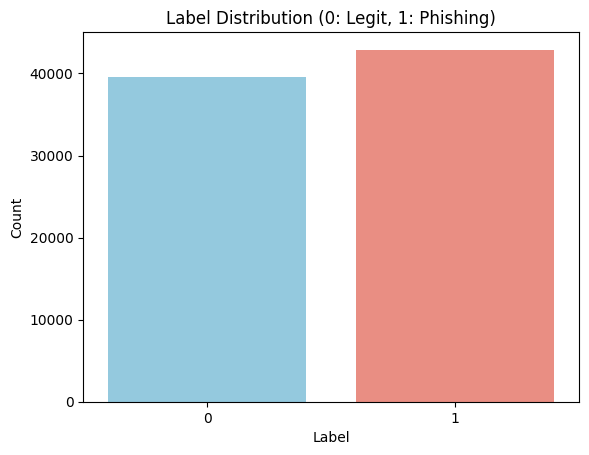

In [17]:
sns.countplot(x='label', data=df, palette={'0': 'skyblue', '1': 'salmon'})
plt.title("Label Distribution (0: Legit, 1: Phishing)")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()



Feature Extraction Function

In [18]:
class MeanEmbeddingVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model): self.model, self.dim = model, model.vector_size
    def fit(self, X, y=None): return self
    def transform(self, X):
        return np.array([np.mean([self.model.wv[w] for w in toks if w in self.model.wv] or [np.zeros(self.dim)], axis=0) for toks in X])

# BERT setup
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')
bert_model.eval()
def bert_embed(texts):
    with torch.no_grad():
        inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=128)
        out = bert_model(**inputs)
        return out.last_hidden_state[:,0,:].numpy()

def extract_features(X, method, w2v_model=None):
    if method=='tfidf':
        vec = TfidfVectorizer(max_features=5000, stop_words='english')
        return vec.fit_transform(X), vec
    if method=='bow':
        vec = CountVectorizer(max_features=5000, stop_words='english')
        return vec.fit_transform(X), vec
    if method=='word2vec':
        tokens = X.apply(simple_preprocess)
        w2v = Word2Vec(tokens, vector_size=100, window=5, min_count=1, workers=4, epochs=10)
        vec = MeanEmbeddingVectorizer(w2v)
        return vec.fit_transform(tokens), vec
    if method=='bert':
        emb = bert_embed(X.tolist())
        return emb, None
    raise ValueError


In [19]:
X_tfidf, vec_tfidf = extract_features(df['clean_text'], 'tfidf')
print("TF-IDF shape:", X_tfidf.shape)

X_bow, vec_bow = extract_features(df['clean_text'], 'bow')
print("BoW shape:", X_bow.shape)

#X_w2v, vec_w2v = extract_features(df['clean_text'], 'word2vec')
#print("Word2Vec shape:", X_w2v.shape)

#X_bert, _ = extract_features(df['clean_text'][:100], 'bert')  # Use a smaller subset to avoid OOM
#print("BERT shape:", X_bert.shape)


TF-IDF shape: (82485, 5000)
BoW shape: (82485, 5000)


Support Vector Machine

In [25]:
from sklearn.svm import LinearSVC


In [26]:
def evaluate_svm(X, y, vec_name, k=5):
    svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    accs, precs, recalls, f1s = [], [], [], []
    all_preds, all_true = [], []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        svm.fit(X_train, y_train)
        preds = svm.predict(X_val)

        accs.append(accuracy_score(y_val, preds))
        precs.append(precision_score(y_val, preds))
        recalls.append(recall_score(y_val, preds))
        f1s.append(f1_score(y_val, preds))

        all_preds.extend(preds)
        all_true.extend(y_val)

        print(f"Fold {fold}: Acc={accs[-1]:.4f}, Prec={precs[-1]:.4f}, Recall={recalls[-1]:.4f}, F1={f1s[-1]:.4f}")

    # Summary Table
    print("\n=== Average Evaluation Metrics ===")
    avg_metrics = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Score': [np.mean(accs), np.mean(precs), np.mean(recalls), np.mean(f1s)]
    })
    print(avg_metrics.to_string(index=False))

    # Confusion Matrix
    cm = confusion_matrix(all_true, all_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Legit (0)', 'Phishing (1)'], yticklabels=['Legit (0)', 'Phishing (1)'])
    plt.title(f"SVM Confusion Matrix - {vec_name.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Bar Plot of Metrics
    plt.figure(figsize=(6, 4))
    sns.barplot(x=avg_metrics['Metric'], y=avg_metrics['Score'], palette='magma')
    plt.title(f"SVM Average Metrics - {vec_name.upper()}")
    plt.ylim(0.5, 1.0)
    plt.tight_layout()
    plt.show()


Fold 1: Acc=0.9811, Prec=0.9803, Recall=0.9832, F1=0.9818
Fold 2: Acc=0.9811, Prec=0.9782, Recall=0.9860, F1=0.9821
Fold 3: Acc=0.9805, Prec=0.9776, Recall=0.9851, F1=0.9814
Fold 4: Acc=0.9793, Prec=0.9747, Recall=0.9857, F1=0.9802
Fold 5: Acc=0.9787, Prec=0.9751, Recall=0.9843, F1=0.9796

=== Average Evaluation Metrics ===
   Metric    Score
 Accuracy 0.980166
Precision 0.977175
   Recall 0.984864
 F1 Score 0.981003


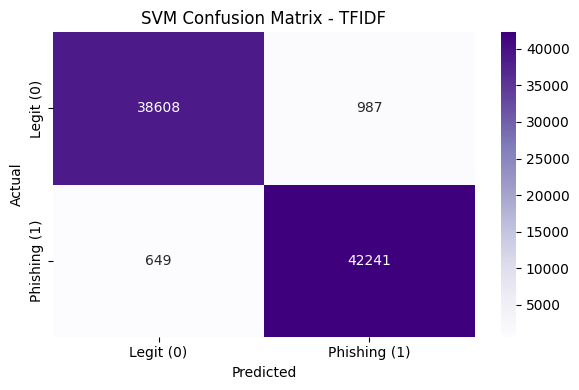

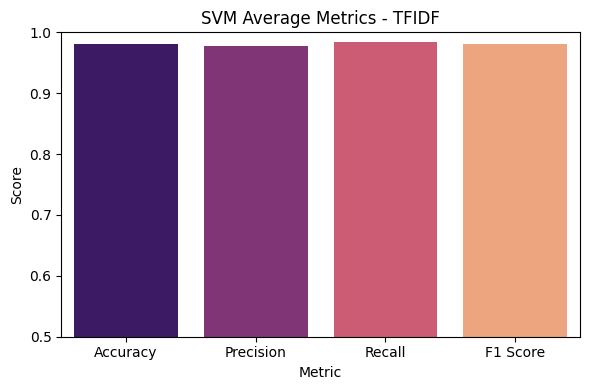

Fold 1: Acc=0.9762, Prec=0.9741, Recall=0.9800, F1=0.9770
Fold 2: Acc=0.9747, Prec=0.9721, Recall=0.9798, F1=0.9760
Fold 3: Acc=0.9762, Prec=0.9724, Recall=0.9823, F1=0.9773
Fold 4: Acc=0.9744, Prec=0.9692, Recall=0.9819, F1=0.9755
Fold 5: Acc=0.9738, Prec=0.9693, Recall=0.9805, F1=0.9749

=== Average Evaluation Metrics ===
   Metric    Score
 Accuracy 0.975074
Precision 0.971421
   Recall 0.980927
 F1 Score 0.976150


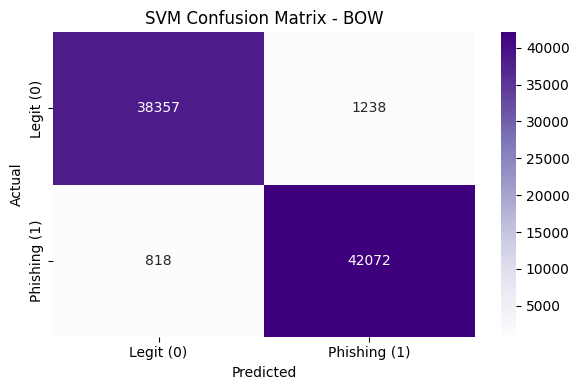

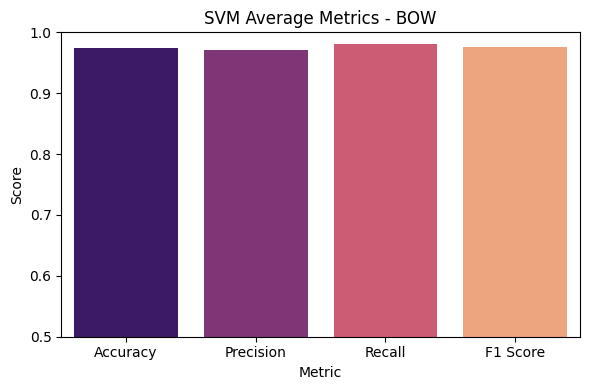

In [27]:
evaluate_svm(X_tfidf.toarray(), y, 'tfidf')
evaluate_svm(X_bow.toarray(), y, 'bow')
